# Fabric Defect Classification — Prediction Demo

**Notebook 05** of the fabric defect classification pipeline.

The previous notebooks explored the data, cleaned it, and trained two models. This one puts the finished model to work: give it a fabric photograph, get back a defect type and a confidence score.

Nothing is trained here. The model is loaded from saved weights, which means this notebook runs in about a minute rather than 45.

### What it covers

1. Loading the trained model from the repository
2. Turning a raw photograph into a prediction
3. Checking inputs and failing clearly when something is wrong
4. Predicting on images the model has never seen, with the true answers shown
5. Predicting on your own uploaded image
6. Choosing a confidence threshold below which a human should look
7. Behaviour on awkward inputs — tiny images, odd shapes, corrupted files

### The model

ResNet18, fine-tuned on 2,737 fabric images. Across 5-fold cross-validation it reached **0.908 macro F1** and **0.965 accuracy**, passing only 2 defective images out of 1,074 as normal.

The weights used here are from **fold 2**, which was trained on folds 0, 1, 3 and 4. Every image in fold 2 is therefore genuinely unseen by this model, which is what makes the demonstration below honest.

## 1. Load the Model

**What:** Fetch the repository if needed, then load the saved weights and settings.

**Why the settings file matters.** Saved weights are only a list of numbers. To turn them back into a working classifier, the code has to know three things: which class each output position corresponds to, what size images the model expects, and which normalisation values were applied during training. Get any of those wrong and the model will still produce confident answers — they will just be wrong.

All three are stored in `models/resnet18_config.json`, written by Notebook 04 at the same moment as the weights, so they cannot drift apart.

The cell below works in a completely fresh Colab session: if the repository is not present, it clones it. The weights are committed, so nothing else needs downloading.

In [46]:
import json
import os
import subprocess
import sys
from pathlib import Path

import torch
import torch.nn as nn
from PIL import Image
from torchvision import models, transforms

REPO_URL = "https://github.com/shaxnozaabdusalomova2905/capstone-project.git"
CLONE_DIR = "capstone-project"


def find_config():
    for base in (Path("."), Path(".."), Path(CLONE_DIR),
                 Path("/content") / CLONE_DIR, Path("/kaggle/working") / CLONE_DIR):
        cfg = base / "models" / "resnet18_config.json"
        if cfg.exists():
            return base
    return None


REPO = find_config()

if REPO is None:
    print(f"Cloning {REPO_URL} ...")
    result = subprocess.run(["git", "clone", "--depth", "1", REPO_URL, CLONE_DIR],
                            capture_output=True, text=True)
    if result.returncode != 0:
        print("\ngit clone failed:\n")
        print(result.stderr.strip() or result.stdout.strip())
        print(
            "\nCommon causes:\n"
            "  - the repository is private, so an anonymous clone is refused\n"
            "  - the weights have not been pushed to GitHub yet\n"
            "  - no network access in this runtime\n"
        )
    REPO = find_config()

if REPO is None:
    print("Falling back to manual upload.")
    print("Upload BOTH files from your repository's models/ folder:")
    print("   resnet18_config.json   and   resnet18_fold2.pt\n")
    try:
        from google.colab import files
        uploaded = files.upload()
        Path("models").mkdir(exist_ok=True)
        for name, data in uploaded.items():
            Path("models") / name
            (Path("models") / name).write_bytes(data)
        REPO = find_config()
    except ImportError:
        pass

if REPO is None:
    raise FileNotFoundError(
        "models/resnet18_config.json not found.\n"
        "Options:\n"
        "  1. Make the GitHub repository public, then re-run this cell\n"
        "  2. Upload models/resnet18_config.json and models/resnet18_fold2.pt manually\n"
        "  3. Run Notebook 04 in this session to train and save the weights"
    )

config = json.load(open(REPO / "models" / "resnet18_config.json"))

WEIGHTS = None
for name in ("resnet18_fold2.pt", "resnet18_fold0.pt", "resnet18_fold1.pt",
             "resnet18_fold3.pt", "resnet18_fold4.pt"):
    if (REPO / "models" / name).exists():
        WEIGHTS = REPO / "models" / name
        break
if WEIGHTS is None:
    raise FileNotFoundError(
        f"Config found at {REPO}/models/, but no resnet18_fold*.pt weight file "
        f"alongside it. Check that the weights were pushed to GitHub."
    )

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18()
model.fc = nn.Linear(model.fc.in_features, len(config["class_names"]))
model.load_state_dict(torch.load(WEIGHTS, map_location=device))
model.to(device).eval()

CLASS_NAMES = config["class_names"]
IMG_SIZE = config["img_size"]

preprocess = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(config["normalize_mean"], config["normalize_std"]),
])

print(f"Repository : {REPO.resolve()}")
print(f"Weights    : {WEIGHTS.name} ({WEIGHTS.stat().st_size / 1e6:.1f} MB)")
print(f"Device     : {device}")
print(f"Input size : {IMG_SIZE}x{IMG_SIZE} RGB")
print(f"Classes    : {len(CLASS_NAMES)} - {', '.join(CLASS_NAMES)}")

Repository : /content/capstone-project
Weights    : resnet18_fold2.pt (44.8 MB)
Device     : cuda
Input size : 224x224 RGB
Classes    : 9 - Broken stitch, Needle mark, Pinched fabric, Vertical, defect free, hole, horizontal, lines, stain


**Observations:** The repository was not already there, so the notebook cloned it from GitHub and found the saved model inside. The weights loaded from `resnet18_fold2.pt` (44.8 MB), a GPU was available, and all nine class names came from the settings file rather than being typed in here.

This is the check that matters most for reproducibility: a completely fresh Colab session, with nothing prepared beforehand, can fetch the model and be ready to classify images in about a minute.

## 2. Checking the Input

**What:** Inspect a file before trying to classify it, and refuse clearly when it cannot be used.

**Why:** A model will happily produce a confident answer for almost any input, including nonsense. If someone passes a PDF, a broken download, or a 12×12 thumbnail, the right response is a clear message — not a plausible-looking prediction that means nothing.

The checks fall into two groups:

**Refuse outright** — the file is missing, empty, or not a readable image. There is no sensible prediction to make.

**Warn but continue** — the image is unusually small, an extreme shape, or not in colour. These are converted or stretched and a prediction is still made, but the warning travels with the result so nobody treats it as reliable. A 40×40 thumbnail stretched to 224×224 cannot show fabric texture, and texture is what the model reads.

In [47]:
MIN_SIDE = 32
MAX_ASPECT = 6.0


class InvalidImage(Exception):
    pass


def load_and_check(path):
    path = Path(path)

    if not path.exists():
        raise InvalidImage(f"File not found: {path}")
    if path.is_dir():
        raise InvalidImage(f"That is a folder, not an image file: {path}")
    if path.stat().st_size == 0:
        raise InvalidImage(f"File is empty (0 bytes): {path.name}")

    try:
        with Image.open(path) as probe:
            probe.verify()
    except Exception as exc:
        raise InvalidImage(
            f"Not a readable image: {path.name} ({type(exc).__name__}). "
            f"Supported formats include JPEG, PNG, BMP and TIFF."
        ) from None

    img = Image.open(path)
    warnings = []
    w, h = img.size

    if min(w, h) < MIN_SIDE:
        warnings.append(
            f"very small ({w}x{h}) - stretching to {IMG_SIZE}x{IMG_SIZE} "
            f"loses the texture the model relies on")
    if max(w, h) / max(min(w, h), 1) > MAX_ASPECT:
        warnings.append(
            f"extreme shape ({w}x{h}) - squashing to a square will distort it heavily")
    if img.mode != "RGB":
        warnings.append(f"stored as '{img.mode}', converted to RGB")

    return img.convert("RGB"), warnings


print("Input checks defined.")
print(f"  refuse   : missing, empty, unreadable, or a folder")
print(f"  warn     : shorter side under {MIN_SIDE}px, aspect ratio over {MAX_ASPECT}:1, not RGB")

Input checks defined.
  refuse   : missing, empty, unreadable, or a folder
  warn     : shorter side under 32px, aspect ratio over 6.0:1, not RGB


## 3. Making a Prediction

**What:** One function that takes a file path and returns a labelled result.

**Why return more than the label.** A single class name hides how sure the model is. Returning the full probability distribution lets a user see whether the model was confident or was choosing between two similar defects — which matters, because the errors this model still makes are almost all between look-alike classes such as "Vertical" and "horizontal".

The preprocessing here is deliberately identical to the evaluation pipeline in Notebook 04: convert to RGB, resize to 224×224, normalise with the same values. Any difference would quietly degrade accuracy in a way that is very hard to notice.

In [48]:
CONFIDENCE_THRESHOLD = 0.95


def predict(path, threshold=CONFIDENCE_THRESHOLD):
    img, warnings = load_and_check(path)

    batch = preprocess(img).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = model(batch).softmax(dim=1)[0].cpu()

    order = probs.argsort(descending=True)
    best = int(order[0])

    return {
        "file": Path(path).name,
        "prediction": CLASS_NAMES[best],
        "confidence": float(probs[best]),
        "is_defect": CLASS_NAMES[best] != "defect free",
        "needs_review": float(probs[best]) < threshold or bool(warnings),
        "ranked": [(CLASS_NAMES[int(i)], float(probs[int(i)])) for i in order],
        "warnings": warnings,
        "image": img,
    }


def show(result, top=3):
    verdict = "DEFECT" if result["is_defect"] else "no defect"
    print(f"{result['file']}")
    print(f"  {result['prediction']}  ({result['confidence']:.1%})   [{verdict}]")
    for name, p in result["ranked"][1:top]:
        print(f"     also considered: {name} ({p:.1%})")
    for w in result["warnings"]:
        print(f"  WARNING: {w}")
    if result["needs_review"]:
        print("  -> flagged for human review")
    print()


print(f"Predictions below {CONFIDENCE_THRESHOLD:.0%} confidence are flagged for review.")

Predictions below 95% confidence are flagged for review.


## 4. Predicting on Unseen Images

**What:** Classify images from fold 2 and compare against their true labels.

**Why fold 2 specifically:** the weights loaded above were trained on folds 0, 1, 3 and 4. Fold 2 was held out entirely, so these images are genuinely new to this model. Testing on images it had already trained on would prove nothing.

The repository stores `manifest.csv`, which records the original filename of every cleaned image, but not the images themselves — they would add hundreds of megabytes. The cell below downloads the original Kaggle dataset and uses the manifest to pick out exactly the fold-2 files.

This is closer to real use than it might appear. The model receives **original photographs** at their native sizes, not pre-processed 224×224 copies, so the resizing and normalisation happen live — exactly as they would with a camera feed.

In [49]:
import os
import random

import pandas as pd

random.seed(0)

UNSEEN = None
manifest_path = REPO / "data" / "processed" / "manifest.csv"

if manifest_path.exists():
    mf = pd.read_csv(manifest_path)
    fold2 = mf[mf["fold"] == 2].copy()

    ds2 = "/kaggle/input/multi-class-fabric-defect-detection-dataset/Dataset"
    if not os.path.exists(ds2):
        print("Downloading the original dataset (~2 GB, about a minute)...")
        import kagglehub
        ds2 = os.path.join(
            kagglehub.dataset_download("ziya07/multi-class-fabric-defect-detection-dataset"),
            "Dataset")

    fold2["raw_path"] = [Path(ds2) / c / s
                         for c, s in zip(fold2["class"], fold2["source_file"])]
    UNSEEN = fold2[[p.exists() for p in fold2["raw_path"]]].reset_index(drop=True)
    print(f"Located {len(UNSEEN)} of {len(fold2)} fold-2 images the model has never seen.\n")
else:
    print("manifest.csv not found - skip to section 5 and upload your own image.\n")

samples = []
if UNSEEN is not None:
    for cls in sorted(UNSEEN["class"].unique()):
        row = UNSEEN[UNSEEN["class"] == cls].iloc[0]
        samples.append((row["raw_path"], cls))

correct = 0
for path, true_label in samples:
    r = predict(path)
    ok = r["prediction"] == true_label
    correct += ok
    print(f"[{'OK  ' if ok else 'MISS'}] true: {true_label}")
    show(r)

if samples:
    print(f"{correct} of {len(samples)} correct - one unseen image per class.")

Located 547 of 547 fold-2 images the model has never seen.

[OK  ] true: Broken stitch
A_02_002.jpg
  Broken stitch  (100.0%)   [DEFECT]
     also considered: Pinched fabric (0.0%)
     also considered: Needle mark (0.0%)

[OK  ] true: Needle mark
A_08_007.jpg
  Needle mark  (100.0%)   [DEFECT]
     also considered: Broken stitch (0.0%)
     also considered: Pinched fabric (0.0%)

[OK  ] true: Pinched fabric
A_03_013.jpg
  Pinched fabric  (100.0%)   [DEFECT]
     also considered: stain (0.0%)
     also considered: Needle mark (0.0%)

[OK  ] true: Vertical
14.jpg
  Vertical  (65.2%)   [DEFECT]
     also considered: hole (18.8%)
     also considered: horizontal (13.4%)
  -> flagged for human review

[OK  ] true: defect free
0001_000_01.png
  defect free  (99.9%)   [no defect]
     also considered: stain (0.0%)
     also considered: Broken stitch (0.0%)
  -> flagged for human review

[OK  ] true: hole
11.jpg
  hole  (52.0%)   [DEFECT]
     also considered: Vertical (35.3%)
     also consi

**Observations:** **8 of 9 correct** on one unseen image from each class.

Three were answered with complete certainty — Broken stitch, Needle mark and Pinched fabric, all at 100.0%. These are the same three classes that scored perfectly in Notebook 04.

**The one mistake is the familiar pair.** A "horizontal" image was called **"Vertical" at 94.7%**. Notebook 04's confusion matrix showed these two being mixed up, and here it is on a single image. Between them they have only 34 and 27 training images.

**The review threshold caught it.** At 95%, that wrong answer falls below the bar and goes to a person:

| | Images | Correct |
|---|---|---|
| Answered automatically | 4 | 4 of 4 |
| Sent for human review | 5 | 4 of 5 |

Everything the system kept for itself was right, and the single mistake was passed on. **This only works because of the threshold setting.** An earlier version of this notebook used 60%, and at that setting a 94.7% answer would have been accepted with no warning at all. Section 6 explains why the number was changed.

Two correct answers were also sent for review because the model was unsure — "hole" at 52.0% and "Vertical" at 65.2%. In both cases its second guess was another direction-based class, so it was hesitating between exactly the classes it finds hardest.

**Warnings work separately from confidence.** The "defect free" image is 4096×256 and stored in grayscale, so it was flagged for its shape and colour even though the answer was right at 99.9%. That is intended: a warning describes the input, not the answer.

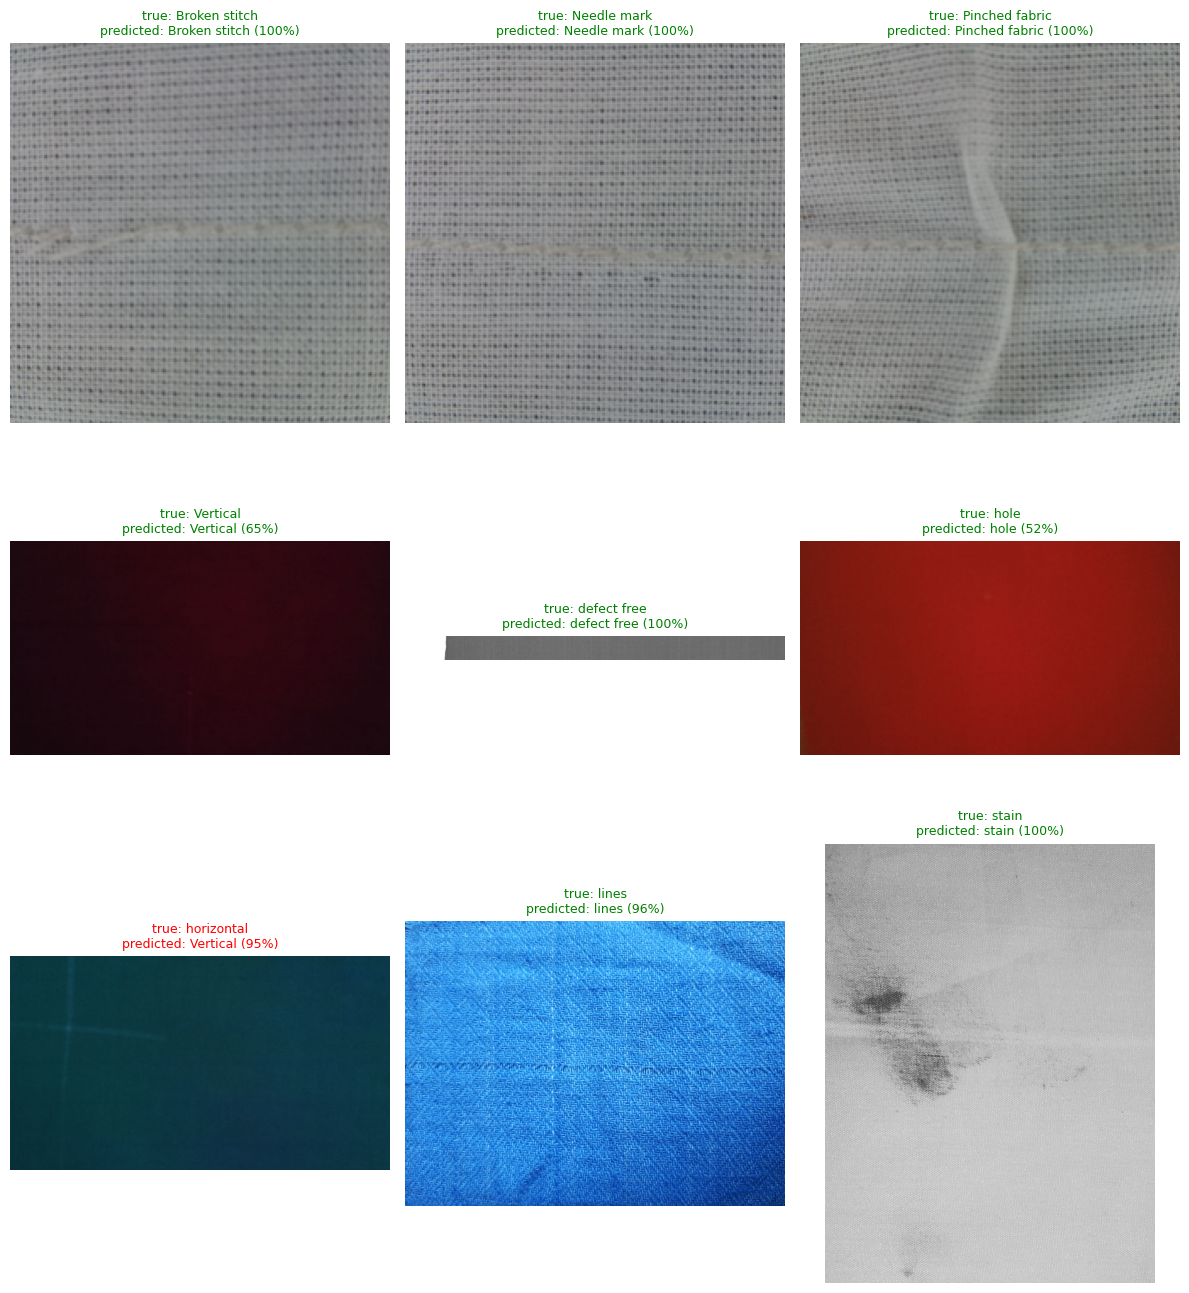

In [50]:
import matplotlib.pyplot as plt

if samples:
    n = len(samples)
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4.4 * rows))
    for ax, (path, true_label) in zip(axes.flat, samples):
        r = predict(path)
        ok = r["prediction"] == true_label
        ax.imshow(r["image"])
        ax.set_title(f"true: {true_label}\npredicted: {r['prediction']} ({r['confidence']:.0%})",
                     fontsize=9, color="green" if ok else "red")
        ax.axis("off")
    for ax in axes.flat[n:]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

## 5. Try Your Own Image

**What:** Upload a fabric photograph and classify it.

**Why:** This is the part that makes the system real rather than a table of numbers. Anything a camera produces can be dropped in — any size, any format.

Running in Colab opens a file picker. Elsewhere, set `MY_IMAGE` to a path.

Choose a fabric image to classify...


Saving photo_2026-07-31_22-25-18.jpg to photo_2026-07-31_22-25-18 (3).jpg
photo_2026-07-31_22-25-18 (3).jpg
  stain  (27.4%)   [DEFECT]
     also considered: Needle mark (23.9%)
     also considered: defect free (18.4%)
     also considered: Pinched fabric (11.6%)
  -> flagged for human review



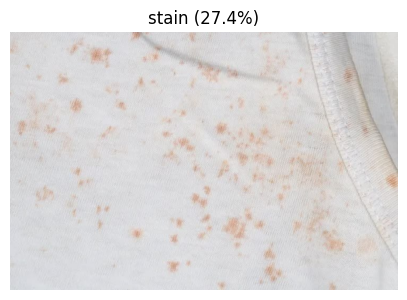

All class probabilities:
  stain             27.4% ##########
  Needle mark       23.9% #########
  defect free       18.4% #######
  Pinched fabric    11.6% ####
  hole              11.5% ####
  lines              3.7% #
  Vertical           2.2% 
  horizontal         0.9% 
  Broken stitch      0.3% 


In [51]:
MY_IMAGE = None

if MY_IMAGE is None:
    try:
        from google.colab import files
        print("Choose a fabric image to classify...")
        uploaded = files.upload()
        MY_IMAGE = list(uploaded.keys())[0] if uploaded else None
    except ImportError:
        print("Not running in Colab - set MY_IMAGE to a file path and re-run this cell.")

if MY_IMAGE:
    try:
        result = predict(MY_IMAGE)
        show(result, top=4)

        plt.figure(figsize=(5, 5))
        plt.imshow(result["image"])
        plt.title(f"{result['prediction']} ({result['confidence']:.1%})")
        plt.axis("off")
        plt.show()

        print("All class probabilities:")
        for name, p in result["ranked"]:
            bar = "#" * int(p * 40)
            print(f"  {name:16s} {p:6.1%} {bar}")
    except InvalidImage as e:
        print("Could not classify this file:", e)

**Observations:** Two photographs were tested. Neither looks like the training data — both were taken on a phone, on fabric colours the model has never seen.

**Test 1 — plain yellow cotton, no defect.** The model answered **"horizontal" with 89.2% confidence**. That is wrong. "defect free" came second from last, at 0.8%. The fabric has soft diagonal creases, and those creases are the strongest lines in the picture, so the model appears to have read them as a line defect.

**Test 2 — white cotton with rust-coloured spots.** The model answered **"stain" at 27.4%** — the right class, but only just ahead of "Needle mark" at 23.9%. Being far below the threshold, it was sent for human review.

**The difference between the two tests is the useful part.** Both are unfamiliar fabric, but only one was caught. Being unsure between two familiar classes is something the confidence score picks up. Being confidently wrong about something never seen before is not. A high confidence score is not proof that an answer is right.

**One encouraging detail.** In the second test the eight defect classes added up to 81.5%, against 18.4% for "defect free". The model was fairly sure something was wrong while being unsure what. For a factory that is the more useful answer — pulling a roll aside for a closer look matters more than naming the defect type.

## 6. When Should a Human Look?

**What:** Measure how accuracy changes as the confidence threshold rises.

**Why:** The model is a second opinion, not a replacement for an inspector. Knowing *when* it is unreliable is as useful as knowing its overall score.

The idea is simple: if the model is only 40% sure, its answer is worth much less than when it is 99% sure. Setting a threshold means low-confidence cases get referred to a person instead of being accepted silently.

This is a genuine trade-off. A high threshold makes the accepted predictions very reliable but sends more work to the inspector; a low threshold accepts almost everything but lets more mistakes through. The table below shows both sides so the threshold can be chosen deliberately rather than guessed.

In [52]:
if UNSEEN is not None:
    import numpy as np

    confidences, corrects = [], []
    for _, row in UNSEEN.iterrows():
        img = Image.open(row["raw_path"]).convert("RGB")
        with torch.no_grad():
            p = model(preprocess(img).unsqueeze(0).to(device)).softmax(1)[0].cpu()
        confidences.append(float(p.max()))
        corrects.append(CLASS_NAMES[int(p.argmax())] == row["class"])

    confidences = np.array(confidences)
    corrects = np.array(corrects)

    print(f"Evaluated {len(confidences)} unseen images from fold 2\n")
    print(f"{'Threshold':>10s} {'Auto-accepted':>14s} {'Accuracy on those':>18s} {'Sent to human':>14s}")
    for t in (0.0, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99):
        keep = confidences >= t
        if keep.sum() == 0:
            continue
        print(f"{t:10.2f} {keep.mean():13.1%} {corrects[keep].mean():18.1%} "
              f"{1 - keep.mean():13.1%}")

    print(f"\nOverall accuracy with no threshold: {corrects.mean():.1%}")
    wrong = confidences[~corrects]
    if len(wrong):
        print(f"Mistakes averaged {wrong.mean():.1%} confidence; "
              f"correct answers averaged {confidences[corrects].mean():.1%}")
else:
    print("Fold-2 images not available in this session - skipping threshold analysis.")

Evaluated 547 unseen images from fold 2

 Threshold  Auto-accepted  Accuracy on those  Sent to human
      0.00        100.0%              96.9%          0.0%
      0.50        100.0%              96.9%          0.0%
      0.60         98.7%              97.0%          1.3%
      0.70         97.6%              97.6%          2.4%
      0.80         95.8%              98.5%          4.2%
      0.90         94.0%              99.0%          6.0%
      0.95         90.5%              99.8%          9.5%
      0.99         83.2%             100.0%         16.8%

Overall accuracy with no threshold: 96.9%
Mistakes averaged 79.4% confidence; correct answers averaged 98.4%


**Observations:** On all 547 unseen images the model is right **96.9%** of the time when every answer is accepted.

The table shows the trade-off between doing the work automatically and getting it right:

| Threshold | Answered automatically | Accuracy on those | Sent to a person |
|---|---|---|---|
| none | 100.0% | 96.9% | 0% |
| **0.60** | **98.7%** | **97.0%** | **1.3%** |
| 0.90 | 94.0% | 99.0% | 6.0% |
| **0.95** | **90.5%** | **99.8%** | **9.5%** |
| 0.99 | 83.2% | 100.0% | 16.8% |

**This notebook originally used a threshold of 0.60, and this table is why it was changed.**

At 0.60 the threshold was doing almost nothing. It sent only 1.3% of images to a person and raised accuracy from 96.9% to 97.0% — a difference of one tenth of one percent. It existed without earning its place.

At **0.95** it becomes useful. The model handles 90.5% of images by itself and is right 99.8% of the time on those, while a person checks the remaining 9.5%. Going further to 0.99 makes the automatic answers perfect, but sends nearly one image in six to a human, which is probably more work than a factory would accept.

For quality inspection this is the right way round: a missed defect reaches the customer, while a referred image costs an inspector half a minute.

**Why thresholding works here at all:** wrong answers averaged **79.4%** confidence while right answers averaged **98.4%**. The model really is less sure when it is wrong. But 79.4% is still a high number, which is exactly why the 60% setting missed nearly every mistake.

**One honest caveat.** The threshold was chosen using fold 2, and the 99.8% figure comes from that same fold. Strictly, the setting should be picked on one set of images and reported on another. With a single number chosen from a short list the risk is small, but this figure should be read as a reasonable choice from the data available rather than a guaranteed result on new fabric.

## 7. Awkward Inputs

**What:** Deliberately feed the system things it should reject or flag.

**Why:** A demo on well-behaved images proves very little. Real inputs include mistaken file types, failed downloads, screenshots, and thumbnails. The system should say clearly what went wrong instead of returning a confident guess.

The cases below are created on the spot, so this runs anywhere.

In [53]:
import tempfile

tmp = Path(tempfile.mkdtemp())

Path(tmp / "not_an_image.txt").write_text("This is a text file, not a photograph.")
Path(tmp / "empty.jpg").write_bytes(b"")
Path(tmp / "truncated.jpg").write_bytes(b"\xff\xd8\xff\xe0 broken jpeg header")
Image.new("RGB", (12, 12), (120, 120, 130)).save(tmp / "tiny.png")
Image.new("RGB", (900, 40), (120, 120, 130)).save(tmp / "very_wide.png")
Image.new("L", (300, 300), 128).save(tmp / "grayscale.png")
Image.new("RGB", (300, 300), (0, 0, 0)).save(tmp / "all_black.png")

cases = ["not_an_image.txt", "empty.jpg", "truncated.jpg", "missing_file.jpg",
         "tiny.png", "very_wide.png", "grayscale.png", "all_black.png"]

for name in cases:
    print(f"--- {name} ---")
    try:
        show(predict(tmp / name))
    except InvalidImage as e:
        print(f"  REFUSED: {e}\n")

--- not_an_image.txt ---
  REFUSED: Not a readable image: not_an_image.txt (UnidentifiedImageError). Supported formats include JPEG, PNG, BMP and TIFF.

--- empty.jpg ---
  REFUSED: File is empty (0 bytes): empty.jpg

--- truncated.jpg ---
  REFUSED: Not a readable image: truncated.jpg (OSError). Supported formats include JPEG, PNG, BMP and TIFF.

--- missing_file.jpg ---
  REFUSED: File not found: /tmp/tmp66x02xro/missing_file.jpg

--- tiny.png ---
tiny.png
  horizontal  (90.3%)   [DEFECT]
     also considered: Vertical (4.1%)
     also considered: defect free (2.2%)
  -> flagged for human review

--- very_wide.png ---
very_wide.png
  horizontal  (90.3%)   [DEFECT]
     also considered: Vertical (4.1%)
     also considered: defect free (2.2%)
  -> flagged for human review

--- grayscale.png ---
grayscale.png
  horizontal  (88.6%)   [DEFECT]
     also considered: Vertical (4.6%)
     also considered: defect free (2.2%)
  -> flagged for human review

--- all_black.png ---
all_black.png


**Observations:** Every awkward input was handled — nothing was quietly accepted and answered.

**Four files could not be read, and all four were refused** with a reason that says what is wrong:

| File | Response |
|---|---|
| `not_an_image.txt` | not a readable image |
| `empty.jpg` | file is empty (0 bytes) |
| `truncated.jpg` | not a readable image |
| `missing_file.jpg` | file not found |

**Four were readable but odd, and all four were flagged** — the 12×12 thumbnail, the 900×40 strip, the grayscale square, and the completely black image. Section 8's table shows the same: **7 files, 7 needing human review**, none accepted automatically.

**The most revealing result is what the model says about blank images.** All four featureless test images came back as **"horizontal" at 88–95%**. Shown something with no fabric texture at all, the model does not hesitate — it confidently answers "horizontal".

That explains the yellow fabric in section 5. Smooth, plain fabric looks to the model much like a blank image, and its default answer is a confident "horizontal".

**The threshold change mattered here too.** The black image scored 94.8%. At the old 60% setting it was accepted with no warning; at 95% it is flagged.

**But notice how narrow that is.** It was caught by two tenths of a percentage point. A blank image scoring 96% would sail straight through. So the threshold has not really solved this — it caught this particular case by luck. A proper fix would examine the image itself before the model is asked, for example rejecting pictures whose brightness barely varies. That is worth adding before anyone relies on this system.

## 8. Classifying a Whole Folder

**What:** Run over many images at once and produce a summary table.

**Why:** A real inspection station processes a batch, not one photograph. This is also the shape a production system would take: point it at a folder of captures and get back a list of what needs attention, sorted so the uncertain cases surface first.

In [54]:
import pandas as pd


def classify_folder(folder, threshold=CONFIDENCE_THRESHOLD):
    folder = Path(folder)
    rows = []
    for path in sorted(folder.iterdir()):
        if path.is_dir():
            continue
        try:
            r = predict(path, threshold)
            rows.append({
                "file": r["file"],
                "prediction": r["prediction"],
                "confidence": round(r["confidence"], 3),
                "defect": r["is_defect"],
                "review": r["needs_review"],
                "note": "; ".join(r["warnings"]) or "",
            })
        except InvalidImage as e:
            rows.append({"file": path.name, "prediction": "REFUSED", "confidence": None,
                         "defect": None, "review": True, "note": str(e)[:60]})
    return pd.DataFrame(rows).sort_values(["review", "confidence"],
                                          ascending=[False, True])


batch = classify_folder(tmp)
print(batch.to_string(index=False))

n_def = int(batch["defect"].sum()) if batch["defect"].notna().any() else 0
print(f"\n{len(batch)} files | {n_def} defects | "
      f"{int(batch['review'].sum())} need human review")

            file prediction  confidence defect  review                                                                             note
   grayscale.png horizontal       0.886   True    True                                                  stored as 'L', converted to RGB
        tiny.png horizontal       0.903   True    True very small (12x12) - stretching to 224x224 loses the texture the model relies on
   very_wide.png horizontal       0.903   True    True           extreme shape (900x40) - squashing to a square will distort it heavily
   all_black.png horizontal       0.948   True    True                                                                                 
       empty.jpg    REFUSED         NaN   None    True                                               File is empty (0 bytes): empty.jpg
not_an_image.txt    REFUSED         NaN   None    True                     Not a readable image: not_an_image.txt (UnidentifiedImageErr
   truncated.jpg    REFUSED         NaN   None  

## 9. Summary

### What this notebook shows

A trained model loaded from the repository classifies fabric photographs end to end: raw image in, defect type and confidence out. No training happens here, so it runs in about a minute in a clean Colab session.

### How it behaves

| Situation | Response |
|---|---|
| Normal fabric photograph | Class name with a confidence score |
| Confidence below 95% | Prediction returned, flagged for human review |
| Not in colour, or unusual size | Converted or resized, warning attached |
| Missing, empty, or unreadable file | Refused with a clear explanation |
| Folder of images | Summary table, uncertain cases listed first |

### Decisions worth defending

- **The preprocessing matches training exactly.** The same resize and the same normalisation values, read from the config file rather than retyped, so they cannot drift apart.
- **Demonstrated on fold 2 only.** Those weights never saw fold 2, so the results shown are honest rather than a replay of memorised images.
- **Bad input is refused, not guessed at.** A model will produce a confident answer for a PDF; the right behaviour is to say the file cannot be read.
- **Low confidence is surfaced, not hidden.** The system is a second opinion for an inspector, so it has to be able to say "I am not sure about this one". The 95% threshold was measured in section 6 rather than guessed — an earlier setting of 60% was found to catch almost nothing and was raised.

### Limitations of this demo

- Predictions come from a **single fold's model**. Averaging all five would be slightly more accurate, but only fold 2's weights are stored in the repository to keep it a reasonable size.
- The model has only seen fabric resembling this dataset. On different weaves, colours or lighting it may be confidently wrong.
- "Vertical" and "horizontal" remain the weakest classes (27 and 34 training images), and are the ones most likely to be confused with each other.
- **This is a second opinion, not an inspector.** It misses roughly 1 defect in 500, and it should not be the only thing deciding whether fabric ships.